In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "../..")

from src.calibration.calibration_plots import calibration_diagnostics
from src.calibration.calibrator import Calibrator
from src.model import MonotonicNN
from src.schemas import OptimizerParams
from src.utils import calculate_brier_metrics, get_best_f1, ice_pdp_plot

## Load and EDA

In [2]:
# Dataset creation
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

df = data["data"].copy()
df["target"] = data["target"]

# 1=malignant, 0=benign
df["target"] = df["target"] + 1
df.loc[df["target"] == 2, "target"] = 0

In [3]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [4]:
# Separate target
y = df["target"].values.astype(np.float32)
X = df.drop(columns=["target"])

In [5]:
ir_tr = float((y == 0).sum() / (y == 1).sum())
n0, n1 = (y == 0).sum(), (y == 1).sum()
mayoritary_label = 0.0 if n0 >= n1 else 1.0

print(f"Imbalance Ratio: {ir_tr:.2f} (n0={n0}, n1={n1})")

Imbalance Ratio: 1.68 (n0=357, n1=212)


In [6]:
# Train / validation / test split
x_tr, x_val_test, y_tr, y_val_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(
    x_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test
)

# Standardize features
scaler = StandardScaler()
x_tr_std = scaler.fit_transform(x_tr)
x_val_std = scaler.transform(x_val)
x_test_std = scaler.transform(x_test)

## Init and fit the model

In [7]:
# Convert to PyTorch tensors
x_tr_t = torch.tensor(x_tr_std, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

x_val_t = torch.tensor(x_val_std, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

x_test_t = torch.tensor(x_val_std, dtype=torch.float32)
y_test_t = torch.tensor(y_val, dtype=torch.float32)

In [8]:
# Define the NN
all_vars = list(x_tr.columns)  # must match column order
non_mon_vars = [
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension",
]
pos_mon_vars = ["mean radius"]
neg_mon_vars = ["smoothness error"]

model = MonotonicNN(
    all_variables=all_vars,
    non_monotonic_vars=non_mon_vars,
    positive_monotonic_vars=pos_mon_vars,
    negative_monotonic_vars=neg_mon_vars,
    hidden_non=16,
    hidden_pos=8,
    hidden_neg=8,
)

In [9]:
# Fit the model
history = model.fit(
    x_tr=x_tr_t,
    y_tr=y_tr_t,
    x_val=x_val_t,
    y_val=y_val_t,
    pos_weight=1.0,
    epochs=100,
    optimizer_params=OptimizerParams(lr=1e-3, weight_decay=1e-5, batch_size=256, patience=5),
    device="cpu",  # or "cuda" if available
    verbose=True,
)

Epoch 1/100 | Train loss: 0.8616 | Val loss: 1.1035
Epoch 2/100 | Train loss: 0.8334 | Val loss: 1.0635
Epoch 3/100 | Train loss: 0.8203 | Val loss: 1.0249
Epoch 4/100 | Train loss: 0.7874 | Val loss: 0.9877
Epoch 5/100 | Train loss: 0.7373 | Val loss: 0.9522
Epoch 6/100 | Train loss: 0.6904 | Val loss: 0.9183
Epoch 7/100 | Train loss: 0.6657 | Val loss: 0.8861
Epoch 8/100 | Train loss: 0.6539 | Val loss: 0.8554
Epoch 9/100 | Train loss: 0.6692 | Val loss: 0.8261
Epoch 10/100 | Train loss: 0.6235 | Val loss: 0.7983
Epoch 11/100 | Train loss: 0.5930 | Val loss: 0.7718
Epoch 12/100 | Train loss: 0.5798 | Val loss: 0.7468
Epoch 13/100 | Train loss: 0.5409 | Val loss: 0.7231
Epoch 14/100 | Train loss: 0.5343 | Val loss: 0.7007
Epoch 15/100 | Train loss: 0.5084 | Val loss: 0.6796
Epoch 16/100 | Train loss: 0.5121 | Val loss: 0.6595
Epoch 17/100 | Train loss: 0.4873 | Val loss: 0.6405
Epoch 18/100 | Train loss: 0.4402 | Val loss: 0.6224
Epoch 19/100 | Train loss: 0.4851 | Val loss: 0.6054
Ep

## Model evaluation

In [10]:
# Predict probs on validation set
probs_tr = model.predict_proba(x_tr_std)
probs_val = model.predict_proba(x_val_std)
probs_test = model.predict_proba(x_test_std)

# Compute best threshold & F1
best_t_tr, best_f1_tr, f1_tr_curve, thresholds = get_best_f1(y_tr, probs_tr)
best_t_val, best_f1_val, f1_val_curve, _ = get_best_f1(y_val, probs_val)
best_t_test, best_f1_test, f1_test_curve, _ = get_best_f1(y_test, probs_test)

print("- Train best F1:", round(best_f1_tr, 4), "at threshold", round(best_t_tr, 4))
print("- Val best F1:", round(best_f1_val, 4), "at threshold", round(best_t_val, 4))
print("- Test best F1:", round(best_f1_test, 4), "at threshold", round(best_t_test, 4))

- Train best F1: 0.9384 at threshold 0.5729
- Val best F1: 0.8772 at threshold 0.7286
- Test best F1: 0.9552 at threshold 0.0251


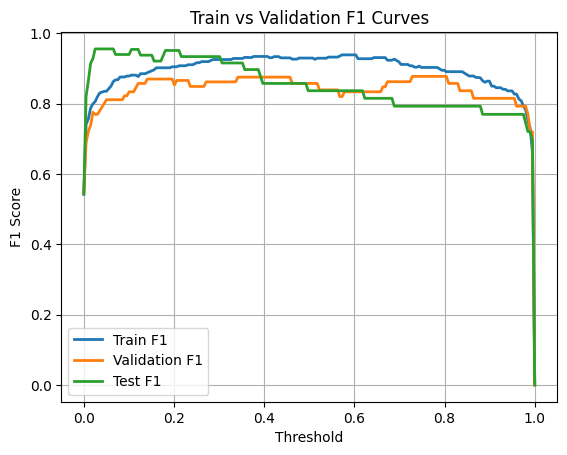

In [11]:
plt.plot(thresholds, f1_tr_curve, label="Train F1", linewidth=2)
plt.plot(thresholds, f1_val_curve, label="Validation F1", linewidth=2)
plt.plot(thresholds, f1_test_curve, label="Test F1", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Curves")
plt.legend()
plt.grid(True)
plt.show()

## Probability calibration

In [12]:
method = "isotonic"

if method == "isotonic":
    cal = Calibrator(method=method)
    cal.fit(probs_val.flatten(), y_val)

    probs_tr_cal = cal.predict_proba(probs_tr.flatten())
    probs_val_cal = cal.predict_proba(probs_val.flatten())
    probs_test_cal = cal.predict_proba(probs_test.flatten())

if method == "temperature":
    # Predict logits
    logits_tr = model.predict_logits(x_tr_std)
    logits_val = model.predict_logits(x_val_std)
    logits_test = model.predict_logits(x_test_std)

    cal = Calibrator(method=method)
    cal.fit(logits_val, y_val_t)

    probs_tr_cal = cal.predict_proba(logits_tr)
    probs_val_cal = cal.predict_proba(logits_val)
    probs_test_cal = cal.predict_proba(logits_test)

In [13]:
# Compute brier score - non calibrated probs
_, _, bss_tr, _ = calculate_brier_metrics(y_tr, probs_tr)
_, _, bss_val, _ = calculate_brier_metrics(y_val, probs_val)
_, _, bss_test, _ = calculate_brier_metrics(y_test, probs_test)
print("Non-calibrated probabilities")
print("- Train bss:", round(bss_tr, 4))
print("- Val bss:", round(bss_val, 4))
print("- Test bss:", round(bss_test, 4))

# Compute brier score - calibrated probs
_, _, bss_tr_cal, _ = calculate_brier_metrics(y_tr, probs_tr_cal)
_, _, bss_val_cal, _ = calculate_brier_metrics(y_val, probs_val_cal)
_, _, bss_test_cal, _ = calculate_brier_metrics(y_test, probs_test_cal)
print()
print("Calibrated probabilities")
print("- Train bss:", round(bss_tr_cal, 4))
print("- Val bss:", round(bss_val_cal, 4))
print("- Test bss:", round(bss_test_cal, 4))

Non-calibrated probabilities
- Train bss: 0.8247
- Val bss: 0.6987
- Test bss: 0.7413

Calibrated probabilities
- Train bss: 0.7961
- Val bss: 0.7643
- Test bss: 0.7371


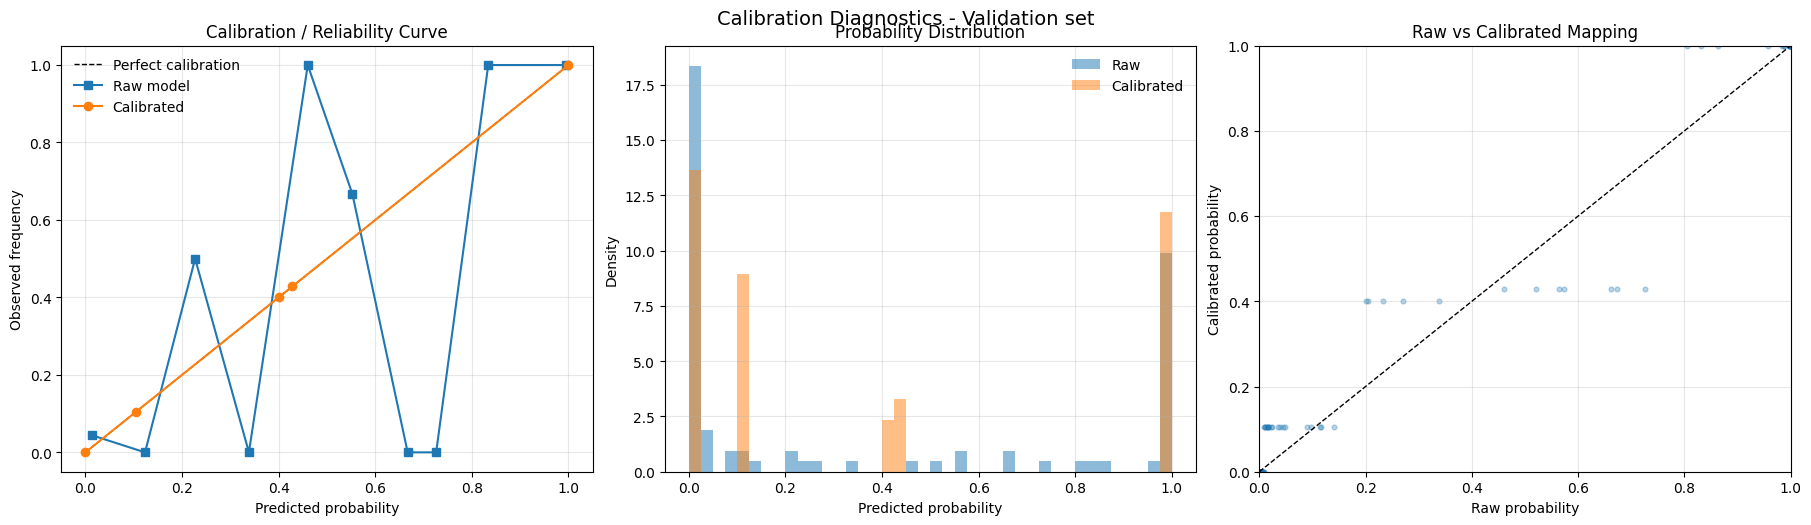

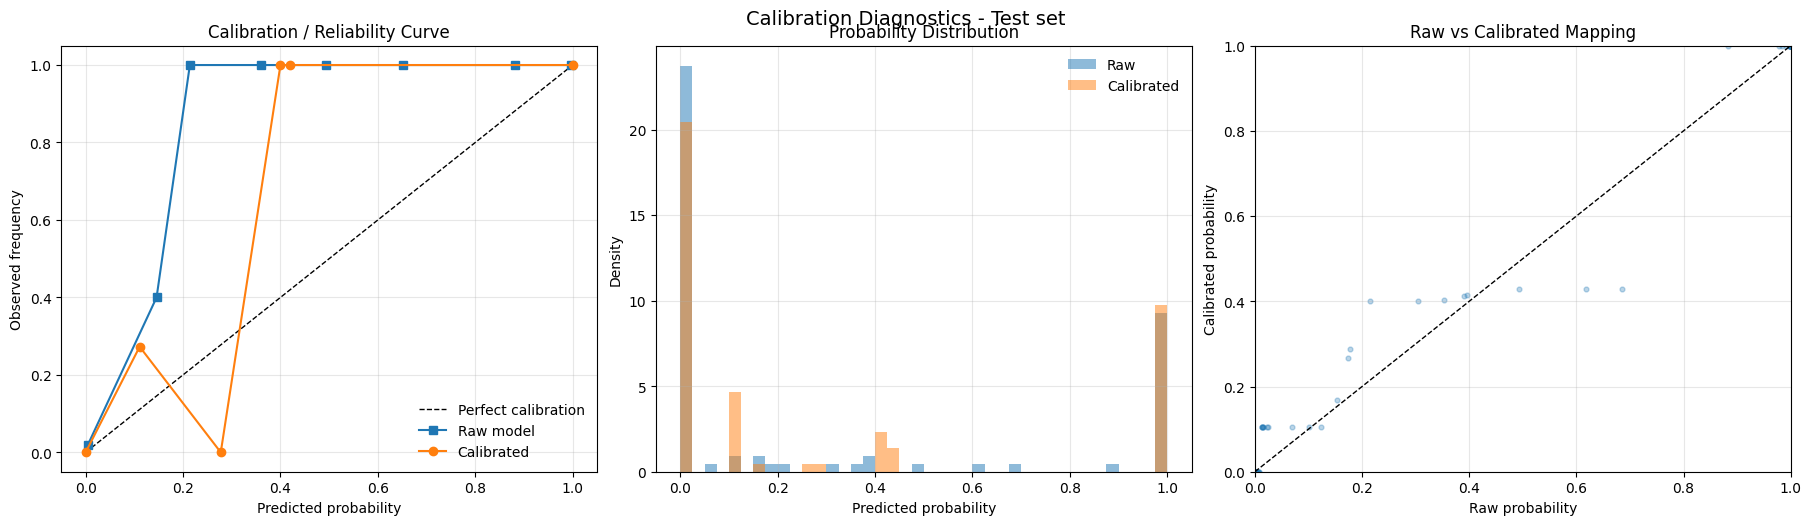

In [14]:
fig, axes = calibration_diagnostics(
    y_val, probs_val, probs_val_cal, n_bins=10, bins=40, suptitle="Calibration Diagnostics - Validation set"
)
fig, axes = calibration_diagnostics(
    y_test, probs_test, probs_test_cal, n_bins=10, bins=40, suptitle="Calibration Diagnostics - Test set"
)
plt.show()

## Partial dependencies

In [15]:
FEATURE_NAME = "mean radius"

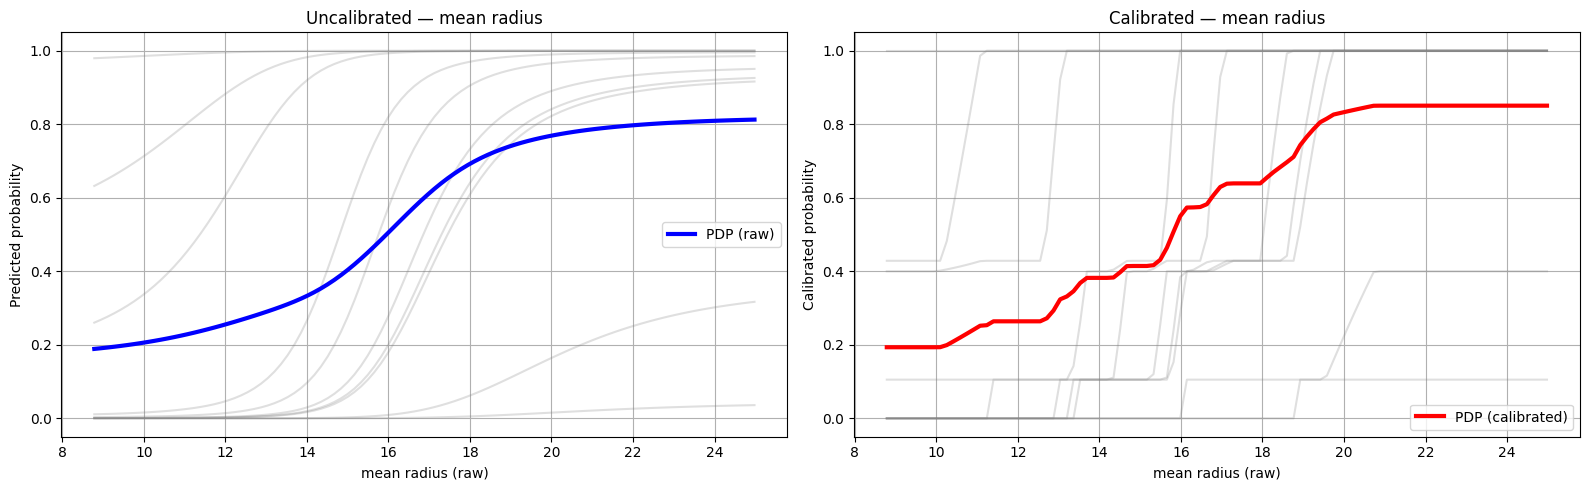

In [16]:
out = ice_pdp_plot(
    model=model,
    X_raw=x_val.values,
    X_std=x_val_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    num_points=100,
    n_samples=10,
    calibrator=cal,
    model_input_space="standardized",
)

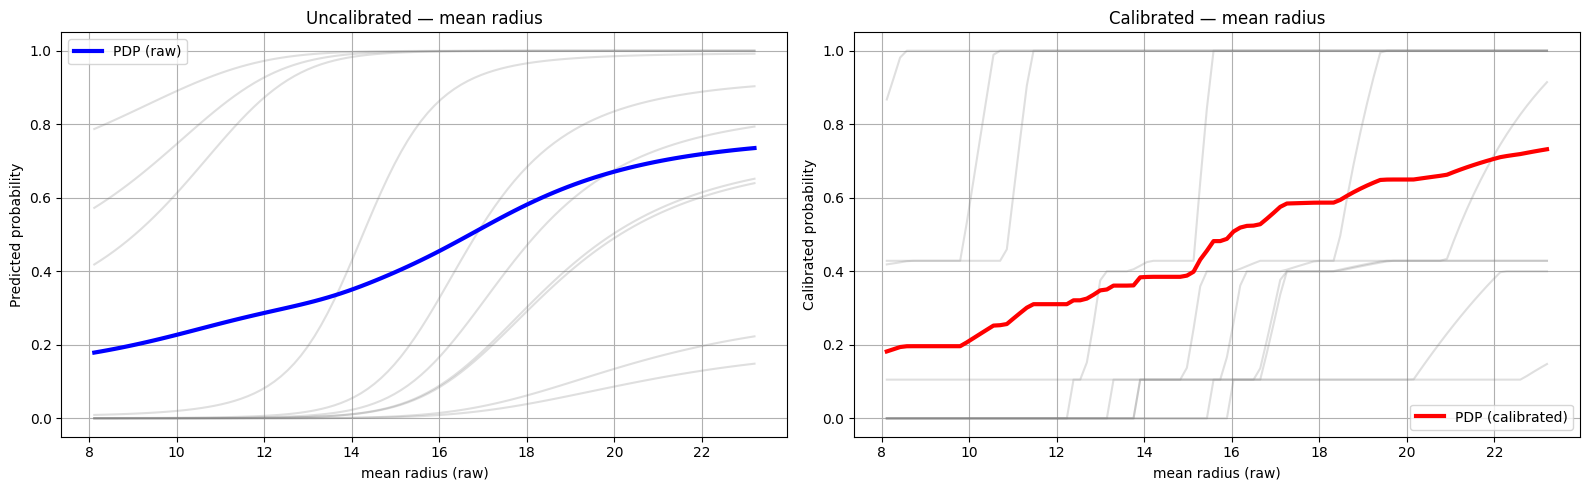

In [17]:
out = ice_pdp_plot(
    model=model,
    X_raw=x_test.values,
    X_std=x_test_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    num_points=100,
    n_samples=10,
    calibrator=cal,
    model_input_space="standardized",
)